In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("HousePrice.csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe7 in position 12: invalid continuation byte

In [3]:
df = pd.read_csv("HousePrice.csv", encoding="latin1")

ParserError: Error tokenizing data. C error: Expected 2 fields in line 16, saw 3


In [4]:
import csv

with open("HousePrice.csv", "r", encoding="latin1") as file:
    for i, line in enumerate(file):
        if i < 20:
            print(i + 1, line.strip())

1 PK-   L$çVøqó×ÿÿÿÿÿÿÿÿ  Housing.csv  u      ä      ën,·
2 ÿèlÝ¥y7q£È8ðqPôí;#R]Hæ4wïP¼¢(Íú¯¯_Þ_o_ïo¯¿ÿúõùùç×¿ß¾ÿw?¾?¿>Þ¼þ|ûØ¿>ß~}ýþ÷ûïóÿ;þ£ï¾ïß¯?>¿ÿûöýþõÇûÛ÷ÇþûëíãëÏý×ïÏýüó_o_ÿÉ¯_ï¿e9¿ýýµüøãøÙï·ï¿üóÚZuþïQ/÷2/ûúß!vÿÄ¯ó&Gøý×2Æg*má¤Î&Êo(h;!{ü­¦@?:ôûøWjGy|Ï£Q8S;Ý*§+ÿVõªÍÒìñ&¤1#U-ãÓ)ÒR¹Au0ÇwMÔ±Ç:¿ý½7Ø"ÔJÔq°ÍÀïþP2Kr-è=N[£_+fqáz¥À,ý(Íí²Ypbð~ðý8Ð4.vk´£ó´ñ)LaPÃÙ.¬~Ý(®8'j]8Z¯^J[f\èÔëÍ2C>Ï¾pN#Â&¼RvÖÁ"y=~Ðf¦¬ÑÞ(Áå±&åA"ÉéQC¤£Y$ÊGÅÄ
3 iKï0àíiþ$l®~º6ÉA¥ÃIê0/Mº ¹¸ù3
4 I·u^ïÄ¼«µ8Òè¢#f$Ä
5 ¼ÒMfi!
6 3ÈÃ*6f²Æý µ¿£=É¤é)ÂTR«ª­Mqå,1Ì´+:¾´×_B§-[8WôúE-!³»âù\EÆcl·ò¨I³ÎÖ3!¤K²Ý{Í
7 Åh¶3¹.ú°f½\Õ"ß+ÂÄ|üª¯è`Õ8£±Ï;Ï³TèuÏût¢ØÙþÄ2Z¨`ç#Æi=å³$í×^«I³V·lë²4²vC
8 Ú±ÕÃ£¥tÈ$ãPÇ`1X©tcÎYn\tv²=wfM
9 «ísÉ0óZÊÁ`ºu;ÆÂTµa}o9ètûæer@Øì¥5[©6fo'*Á²{¦ËfWµvªª©Ëw¼á[&BÚ:Þ4úþ9Û¯@®Þtþ	Ñ_©Éãó.DÈ?^6¹¼	lúFØEOëZX+Ç×ãd»

In [5]:
df.head()

NameError: name 'df' is not defined

In [6]:
df = pd.read_csv("HousePrice.csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe7 in position 12: invalid continuation byte

In [7]:
import csv

with open("HousePrice.csv", "r", encoding="latin1") as file:
    for i, line in enumerate(file):
        if i < 20:
            print(i + 1, line.strip())

1 PK-   L$çVøqó×ÿÿÿÿÿÿÿÿ  Housing.csv  u      ä      ën,·
2 ÿèlÝ¥y7q£È8ðqPôí;#R]Hæ4wïP¼¢(Íú¯¯_Þ_o_ïo¯¿ÿúõùùç×¿ß¾ÿw?¾?¿>Þ¼þ|ûØ¿>ß~}ýþ÷ûïóÿ;þ£ï¾ïß¯?>¿ÿûöýþõÇûÛ÷ÇþûëíãëÏý×ïÏýüó_o_ÿÉ¯_ï¿e9¿ýýµüøãøÙï·ï¿üóÚZuþïQ/÷2/ûúß!vÿÄ¯ó&Gøý×2Æg*má¤Î&Êo(h;!{ü­¦@?:ôûøWjGy|Ï£Q8S;Ý*§+ÿVõªÍÒìñ&¤1#U-ãÓ)ÒR¹Au0ÇwMÔ±Ç:¿ý½7Ø"ÔJÔq°ÍÀïþP2Kr-è=N[£_+fqáz¥À,ý(Íí²Ypbð~ðý8Ð4.vk´£ó´ñ)LaPÃÙ.¬~Ý(®8'j]8Z¯^J[f\èÔëÍ2C>Ï¾pN#Â&¼RvÖÁ"y=~Ðf¦¬ÑÞ(Áå±&åA"ÉéQC¤£Y$ÊGÅÄ
3 iKï0àíiþ$l®~º6ÉA¥ÃIê0/Mº ¹¸ù3
4 I·u^ïÄ¼«µ8Òè¢#f$Ä
5 ¼ÒMfi!
6 3ÈÃ*6f²Æý µ¿£=É¤é)ÂTR«ª­Mqå,1Ì´+:¾´×_B§-[8WôúE-!³»âù\EÆcl·ò¨I³ÎÖ3!¤K²Ý{Í
7 Åh¶3¹.ú°f½\Õ"ß+ÂÄ|üª¯è`Õ8£±Ï;Ï³TèuÏût¢ØÙþÄ2Z¨`ç#Æi=å³$í×^«I³V·lë²4²vC
8 Ú±ÕÃ£¥tÈ$ãPÇ`1X©tcÎYn\tv²=wfM
9 «ísÉ0óZÊÁ`ºu;ÆÂTµa}o9ètûæer@Øì¥5[©6fo'*Á²{¦ËfWµvªª©Ëw¼á[&BÚ:Þ4úþ9Û¯@®Þtþ	Ñ_©Éãó.DÈ?^6¹¼	lúFØEOëZX+Ç×ãd»

In [8]:
df = pd.read_csv("HousePrice.csv", encoding="latin1", sep=None, engine="python")

ParserError: ',' expected after '"'

In [9]:
df = pd.read_csv(
    "HousePrice.csv",
    encoding="latin1",
    on_bad_lines="skip"
)

df.head()

,PK-,·
0,ÿèlÝ¥y 7q£È8ðqPôí;#R]Hæ4wïP¼¢(Íú¯¯...,ý(Íí²Ypbð~ðý8Ð4.vk´£ó ´ñ)LaPÃÙ.¬~...
1,iKï0àíiþ$l®~º6 ÉA¥ÃIê0/Mº,NaN
2,I·u^ïÄ¼«µ8Òè¢#f$Ä,NaN
3,¼ÒMfi!,NaN
4,3ÈÃ*6f²Æý µ¿ £=É¤é)ÂTR«ª­Mqå,1Ì´+:¾´×_B§-[8WôúE-!³»âù\EÆcl ·...


In [10]:
df.shape

(33, 2)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   PK-   33 non-null     object
 1   ·       10 non-null     object
dtypes: object(2)
memory usage: 660.0+ bytes


In [12]:
df.isnull().sum()

,0
PK-,0
·,23


In [13]:
df.columns

Index(['PK-', '·'], dtype='object')

In [14]:
df.columns

Index(['PK-', '·'], dtype='object')

In [15]:
df.dtypes

,0
PK-,object
·,object


In [16]:
df = df.dropna()

In [17]:
df.isnull().sum()

,0
PK-,0
·,0


In [18]:
X = df[['Area']]
y = df['Price']

KeyError: "None of [Index(['Area'], dtype='object')] are in the [columns]"

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NameError: name 'X' is not defined

In [20]:
print(df.columns.tolist())

['PK\x03\x04-', '·']


In [21]:
print(df.columns.tolist())

['PK\x03\x04-', '·']


In [22]:
X = df[['Area']]
y = df['Price']

KeyError: "None of [Index(['Area'], dtype='object')] are in the [columns]"

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NameError: name 'X' is not defined

In [24]:
print(df.columns.tolist())

['PK\x03\x04-', '·']


In [25]:
model = LinearRegression()

In [26]:
model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [27]:
import os

print(os.listdir('/content'))

['.config', 'HousePrice.csv', 'sample_data']


In [28]:
import zipfile
import io

with zipfile.ZipFile('/content/HousePrice.csv') as z:
    data = z.read('Housing.csv')

df = pd.read_csv(io.BytesIO(data))

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [29]:
print("Shape of dataset:", df.shape)

Shape of dataset: (545, 13)


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [31]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [32]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [33]:
print(df.select_dtypes(include='object').columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [34]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [35]:
print(df_encoded.shape)
print(df_encoded.columns)

(545, 14)
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [36]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [37]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (545, 13)
Target: (545,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


In [39]:
model = LinearRegression()

In [40]:
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [42]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [43]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 970043.4039201636


In [44]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 1754318687330.6638


In [45]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6529242642153184


In [46]:
print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("R²  :", r2)

Model Evaluation
-----------------
MAE : 970043.4039201636
MSE : 1754318687330.6638
R²  : 0.6529242642153184


In [47]:
results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'R²'],
    'Value': [mae, mse, r2]
})

results

,Metric,Value
0,MAE,9.700434e+05
1,MSE,1.754319e+12
2,R²,6.529243e-01


In [48]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


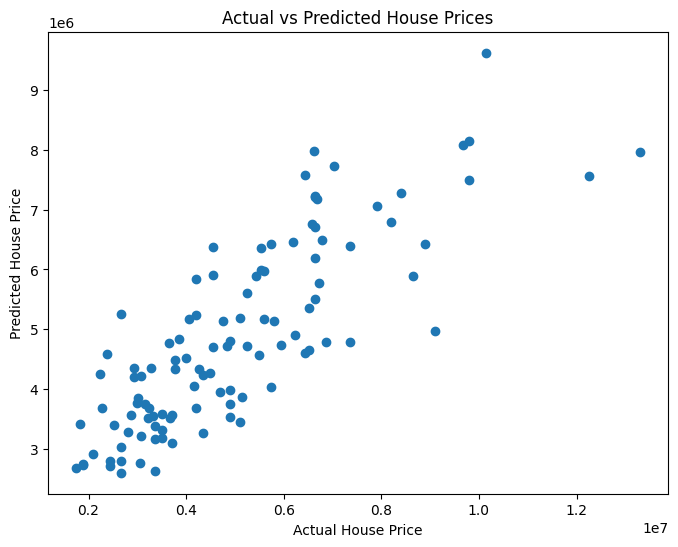

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [50]:
X_simple = df[['area']]
y_simple = df['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

y_pred_s = simple_model.predict(X_test_s)

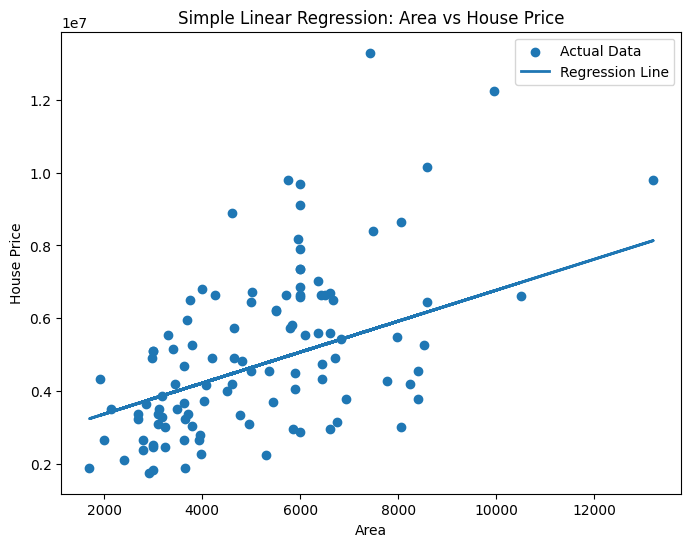

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(X_test_s, y_test_s, label='Actual Data')

plt.plot(
    X_test_s,
    y_pred_s,
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("Area")
plt.ylabel("House Price")
plt.title("Simple Linear Regression: Area vs House Price")
plt.legend()

plt.show()

In [52]:
mae_simple = mean_absolute_error(y_test_s, y_pred_s)
mse_simple = mean_squared_error(y_test_s, y_pred_s)
r2_simple = r2_score(y_test_s, y_pred_s)

print("Simple Linear Regression")
print("------------------------")
print("MAE:", mae_simple)
print("MSE:", mse_simple)
print("R²:", r2_simple)

Simple Linear Regression
------------------------
MAE: 1474748.1337969352
MSE: 3675286604768.185
R²: 0.27287851871974644


In [53]:
comparison = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression'
    ],
    'MAE': [
        mae_simple,
        mae
    ],
    'MSE': [
        mse_simple,
        mse
    ],
    'R²': [
        r2_simple,
        r2
    ]
})

comparison

,Model,MAE,MSE,R²
0,Simple Linear Regression,1.474748e+06,3.675287e+12,0.272879
1,Multiple Linear Regression,9.700434e+05,1.754319e+12,0.652924


## Conclusion

In this task, Linear Regression was implemented to predict house prices using the House Price dataset. The dataset was first explored and categorical variables were converted into numerical form using one-hot encoding.

The dataset was divided into training and testing sets using an 80:20 ratio. A Simple Linear Regression model was developed using area as the predictor, while a Multiple Linear Regression model used multiple house-related features.

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² score. The results show how well the models can predict house prices and how much variation in house prices is explained by the selected features.

The regression coefficients were also analyzed to understand the relationship between the input features and house prices.